In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Superstore sales dataset.csv",parse_dates=['Order Date','Ship Date'],encoding='latin 1')

In [3]:
print("null values in each column:")
print(df.isnull().sum())

null values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [14]:
print("number of duplicate rows:",
      df.duplicated().sum())

number of duplicate rows: 0


In [15]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [16]:
df['Order Date'] =pd.to_datetime(df['Order Date'],dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'],dayfirst=True)

In [17]:
df['ShippingDays']=(df['Ship Date']-df['Order Date']).dt.days

In [18]:
df[['Order Date','Ship Date','ShippingDays']].head()

,Order Date,Ship Date,ShippingDays
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [19]:
df['ProfitMargin']=(df['Profit'] / df.Sales)*100

In [20]:
df[['Order Date','Ship Date','ShippingDays','ProfitMargin']].head()

,Order Date,Ship Date,ShippingDays,ProfitMargin
0,2016-11-08,2016-11-11,3,16.00
1,2016-11-08,2016-11-11,3,30.00
2,2016-06-12,2016-06-16,4,47.00
3,2015-10-11,2015-10-18,7,-40.00
4,2015-10-11,2015-10-18,7,11.25


In [21]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,ShippingDays,ProfitMargin
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896,3.958175,12.031393
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000,-275.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,3.000000,7.500000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,4.000000,27.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,5.000000,36.250000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,7.000000,50.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.747567,46.675435


In [22]:
import matplotlib.pyplot as plt

In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True)

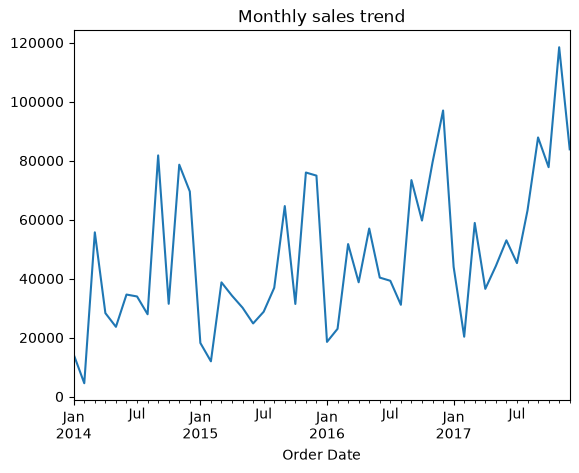

In [24]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df.resample('ME',on='Order Date')['Sales'].sum().plot()
plt.title('Monthly sales trend')
plt.show()

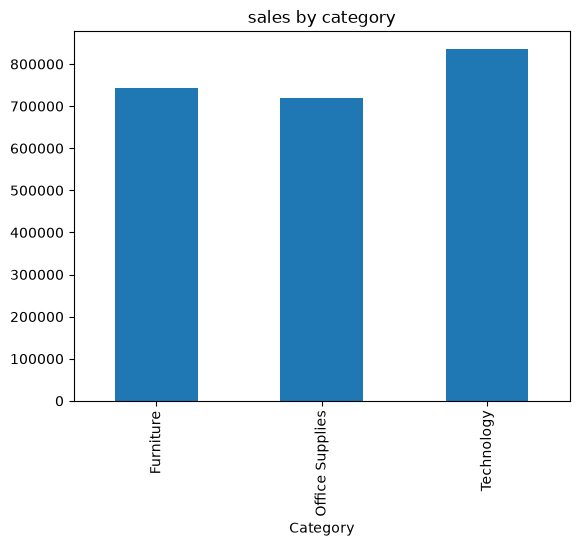

In [25]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title('sales by category')
plt.show()

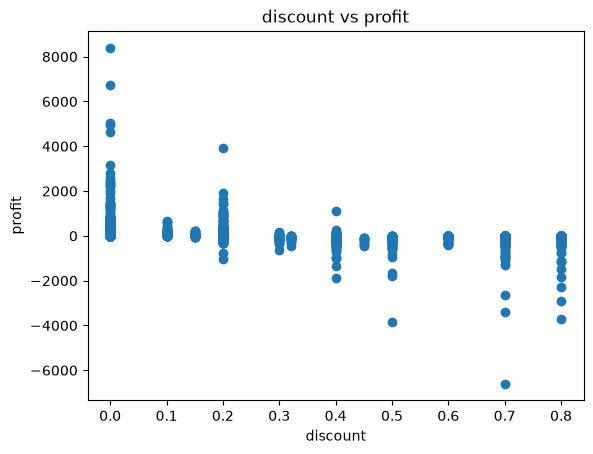

In [26]:
plt.scatter(df['Discount'],
df['Profit'])
plt.title('discount vs profit')
plt.xlabel('discount')
plt.ylabel('profit')
plt.show()

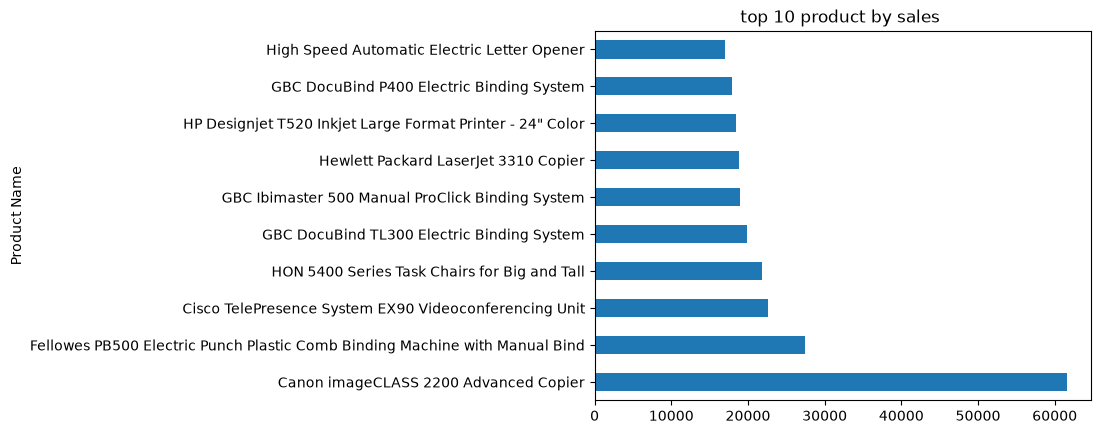

In [27]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('top 10 product by sales ')
plt.show()

In [28]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

In [29]:
df[['Discount','Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


In [30]:
df['ProfitMargin']=df['Profit']/df['Sales']
df.groupby('Category')['ProfitMargin'].mean().sort_values().head(1)

Category
Furniture    0.038784
Name: ProfitMargin, dtype: float64

In [31]:
df['ShippingDays'] = (df['Ship Date']-df['Order Date']).dt.days
df.groupby('Ship Mode')['ShippingDays'].mean()

Ship Mode
First Class       2.182705
Same Day          0.044199
Second Class      3.238046
Standard Class    5.006535
Name: ShippingDays, dtype: float64

In [32]:
 from sklearn.linear_model import LogisticRegression

In [33]:
from sklearn.model_selection import train_test_split


In [34]:
x=df[['Quantity','Discount','ShippingDays']]

In [35]:
Y=(df['Profit']>0).astype(int)

In [36]:
X_train,X_test,Y_train,Y_test=train_test_split(x,Y,test_size=0.2,random_state=42)

In [37]:
model=LogisticRegression().fit(X_train,Y_train)

In [38]:
print(model.score(X_test,Y_test)) 

0.9344672336168084


In [39]:
import seaborn as sns

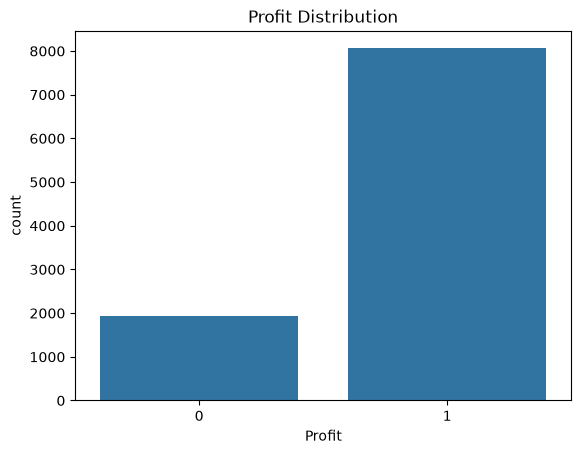

In [40]:
plt.Figure(figsize=(6,4))
sns.countplot(x=Y)
plt.title("Profit Distribution")
plt.show()

In [41]:
import matplotlib.pyplot as plt

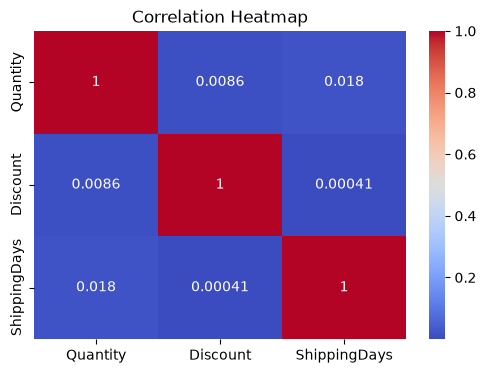

In [42]:
plt.figure(figsize=(6,4))
sns.heatmap(x.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

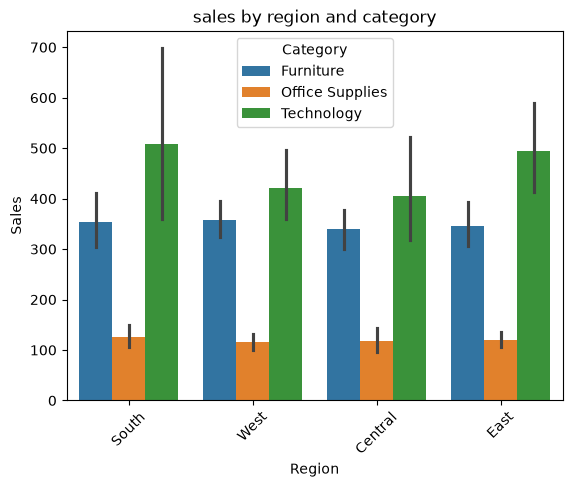

In [43]:
plt.Figure(figsize=(10,5))
sns.barplot(data=df,x="Region",y="Sales",hue="Category")
plt.title("sales by region and category")
plt.xticks(rotation=45)
plt.show()

In [44]:
Key Insights from the Python Analysis:
1. Profit vs Loss: Most orders are profitable. The number of Profit = 1 orders is much higher than Loss = 0 orders.
2. Discount Impact: The correlation heatmap shows Discount has a negative correlation with other features, higher discounts are linked to lower performance in other areas.
3. Top Sales Segment: Technology is the highest selling category in all 4 regions. The East and South regions have the highest total sales, driven mainly by Technology.

3 DataDriven Business Recommendations:
1. Investigate Loss Orders: Analyze the small group of loss-making orders to find root causes like high discounts, returns, or shipping costs, and reduce them.
2. Optimize Discount Strategy: Avoid company-wide discounts,Use targeted discounts only for low-performing categories/regions to protect margins.
3. Double Down on Technology in East/South: Allocate more inventory, marketing budget, and promotions to Technology products in the East and South regions where demand is strongest.

SyntaxError: invalid syntax (2519040675.py, line 1)